### Project Summary

**Project — Employee Attrition Prediction (HR Analytics)**

**Problem:** Predict whether an employee will leave (Attrition = Yes/No) using HR features (demographics, job role, job satisfaction, compensation, tenure, work environment, etc.). This supports HR teams to proactively retain talent.

**Dataset:** IBM HR Attrition dataset (`WA_Fn-UseC_-HR-Employee-Attrition.csv`) — ~1–2k rows (common public dataset). If you have a different internal dataset, the pipeline adapts easily.

**Approach & Steps Implemented:**
* Exploratory Data Analysis (target imbalance, feature distributions).
* Preprocessing: missing-value imputation, categorical encoding (one-hot), numeric scaling.
* Addressed class imbalance using **SMOTE** (optional).
* Models: **Logistic Regression** (interpretable baseline) and **Random Forest** (strong tree ensemble).
* Evaluations: Accuracy, Precision, Recall, F1, ROC-AUC, PR curves, Confusion Matrices.
* Explainability: **SHAP** (if installed) to interpret feature impacts on predictions.
* Visualizations: target distribution, ROC, PR curves, feature importances, SHAP summary, and saving figures.
* Saved the best model & preprocessing artifacts for deployment.

**Key Business Value:**
* Enables HR teams to identify employees at risk of leaving and design targeted retention actions (compensation, role change, training).
* Reduces hiring costs and productivity loss by focusing retention efforts on high-risk employees.
* SHAP-based explanations increase trust and enable HR to understand drivers of attrition (e.g., low job satisfaction, long commute, low salary).

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# optional imports
try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False


In [3]:
# ---------------------
# 1. Load dataset
# ---------------------
# dataset link : https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

DATA_PATH = "Data/WA_Fn-UseC_-HR-Employee-Attrition.csv"  # change path if needed
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Download IBM HR Attrition CSV and place it there.")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


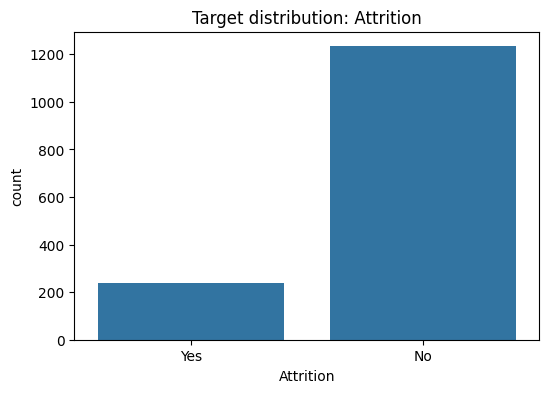

Numeric cols sample: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate']


In [4]:
# ---------------------
# 2. Quick EDA
# ---------------------
os.makedirs("figures_attrition", exist_ok=True)

plt.figure(figsize=(6,4))
sns.countplot(x="Attrition", data=df)
plt.title("Target distribution: Attrition")
plt.savefig("figures_attrition/target_dist.png")
plt.show()

# show few numeric distributions
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric cols sample:", numeric_cols[:8])

In [6]:
# ---------------------
# 3. Preprocessing
# ---------------------
# Drop employeeID or irrelevant cols if present
if 'EmployeeNumber' in df.columns:
    df = df.drop(columns=['EmployeeNumber'])

# Target encoding: Attrition Yes/No -> 1/0
df['AttritionFlag'] = df['Attrition'].map({'Yes':1,'No':0}) if 'Attrition' in df.columns else df[df.columns[-1]]

# Choose features: drop original Attrition column and other textual id columns
drop_cols = ['Attrition'] if 'Attrition' in df.columns else []
# Some columns not useful or leak information (if present) - adjust as dataset specifics
for c in ['EmployeeCount','Over18','StandardHours']:
    if c in df.columns:
        drop_cols.append(c)

# Build feature list
features = [c for c in df.columns if c not in drop_cols + ['AttritionFlag']]
# Separate numeric / categorical
num_cols = [c for c in features if df[c].dtype in [np.int64, np.float64]]
cat_cols = [c for c in features if c not in num_cols]

print(f"Numeric features ({len(num_cols)}): {num_cols[:10]}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols[:20]}")

# Simple missing value handling
for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna("missing")

# Build preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ], remainder='drop'
)

# Prepare X, y
X = df[features].copy()
y = df['AttritionFlag'].copy()

Numeric features (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome']
Categorical features (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [7]:
# ---------------------
# 4. Train-test split
# ---------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train / Test shapes:", X_train.shape, X_test.shape)

Train / Test shapes: (1176, 30) (294, 30)


In [8]:
# ---------------------
# 5. Handle imbalance (optional)
# ---------------------
use_smote = True
if use_smote and IMBLEARN_AVAILABLE:
    print("Using SMOTE to oversample minority class on training set")
    # Preprocess numeric & categorical separately then SMOTE (SMOTE requires numeric array)
    X_train_pre = preprocessor.fit_transform(X_train)
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train_pre, y_train.values)
    # Note: we will train models on X_res; for pipelines we can keep a separate preprocessor
    X_train_final = X_res
    y_train_final = y_res
else:
    # keep pipeline training (fit preprocessor inside pipeline)
    X_train_final = X_train
    y_train_final = y_train

Using SMOTE to oversample minority class on training set


In [9]:
# ---------------------
# 6. Model training
# ---------------------
models = {}

# 6A Logistic Regression baseline (use pipeline)
pipe_lr = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
if use_smote and IMBLEARN_AVAILABLE:
    # train directly on numeric SMOTE output
    # fit logistic on X_train_final (array) - we need to bypass pipeline (preprocessor already applied)
    pipe_lr_no_pre = LogisticRegression(max_iter=1000, class_weight='balanced')
    pipe_lr_no_pre.fit(X_train_final, y_train_final)
    models['LogisticRegression'] = ('preprocessed', pipe_lr_no_pre)
else:
    pipe_lr.fit(X_train, y_train)
    models['LogisticRegression'] = ('pipeline', pipe_lr)

# 6B Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
if use_smote and IMBLEARN_AVAILABLE:
    rf.fit(X_train_final, y_train_final)
else:
    pipe_rf = Pipeline(steps=[('preproc', preprocessor), ('clf', rf)])
    pipe_rf.fit(X_train, y_train)
    rf = pipe_rf
models['RandomForest'] = ('pipeline' if not (use_smote and IMBLEARN_AVAILABLE) else 'preprocessed', rf)

# Optional: LightGBM/XGBoost can be added similarly


=== Evaluation: LogisticRegression ===
Accuracy: 0.7653061224489796
Precision: 0.35526315789473684
Recall: 0.574468085106383
F1: 0.43902439024390244

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.80      0.85       247
           1       0.36      0.57      0.44        47

    accuracy                           0.77       294
   macro avg       0.63      0.69      0.65       294
weighted avg       0.82      0.77      0.79       294



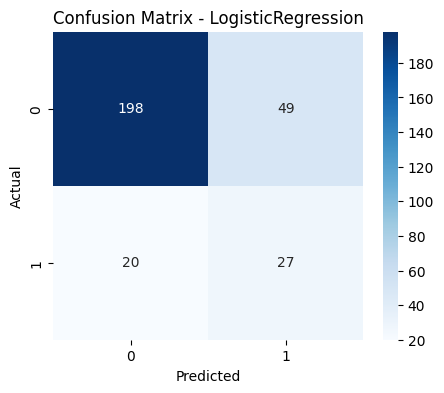

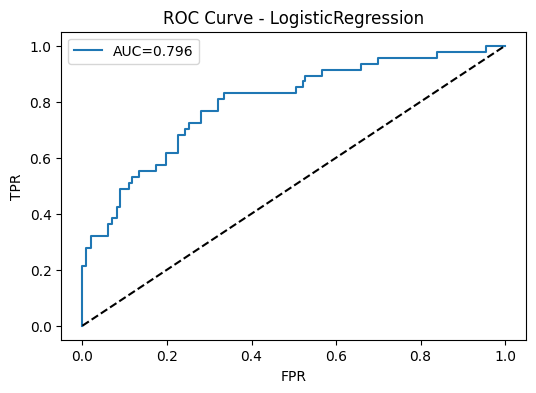

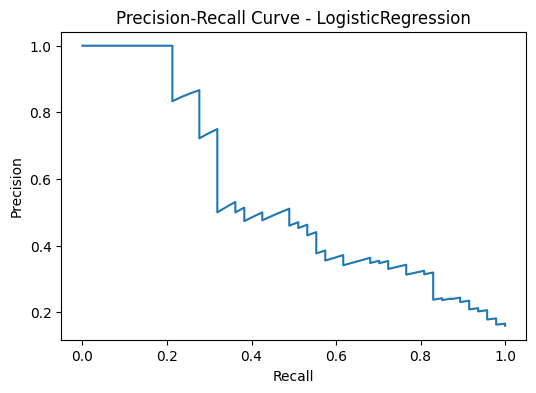


=== Evaluation: RandomForest ===
Accuracy: 0.8435374149659864
Precision: 0.5217391304347826
Recall: 0.2553191489361702
F1: 0.34285714285714286

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.52      0.26      0.34        47

    accuracy                           0.84       294
   macro avg       0.70      0.61      0.63       294
weighted avg       0.82      0.84      0.82       294



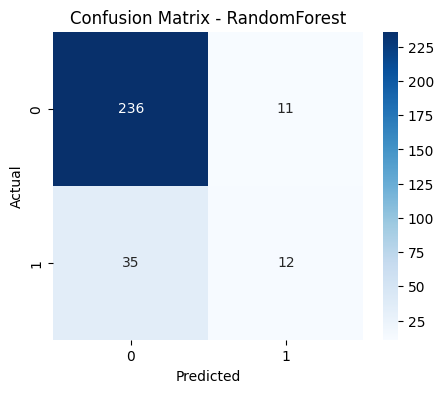

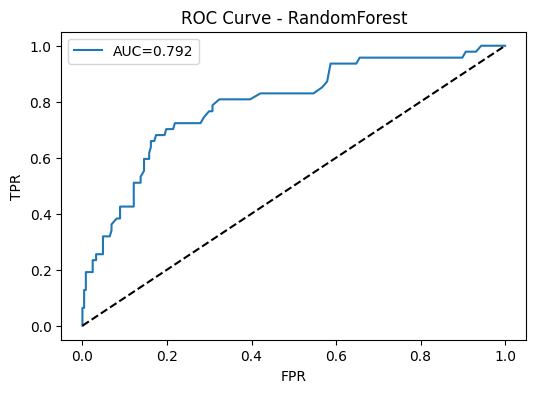

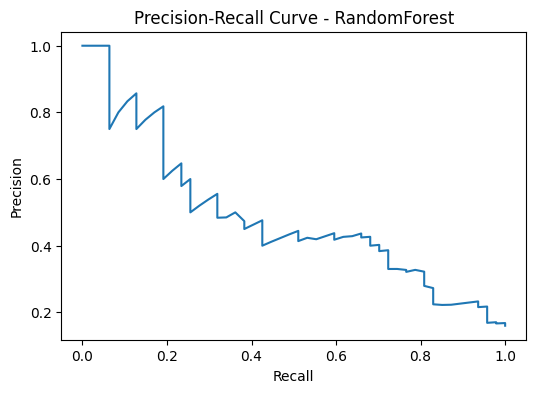

In [10]:
# ---------------------
# 7. Evaluation utilities
# ---------------------
def eval_and_plot(model_entry, Xt, yt, name):
    mode, mdl = model_entry
    if mode == 'pipeline':
        y_pred = mdl.predict(Xt)
        if hasattr(mdl, "predict_proba"):
            y_prob = mdl.predict_proba(Xt)[:,1]
        else:
            # get probability from final estimator if pipeline
            try:
                y_prob = mdl.named_steps['clf'].predict_proba(mdl.named_steps['preproc'].transform(Xt))[:,1]
            except Exception:
                y_prob = None
    else:
        # preprocessed arrays: need to transform test set first
        Xt_pre = preprocessor.transform(Xt)
        y_pred = mdl.predict(Xt_pre)
        y_prob = mdl.predict_proba(Xt_pre)[:,1] if hasattr(mdl, "predict_proba") else None

    print(f"\n=== Evaluation: {name} ===")
    print("Accuracy:", accuracy_score(yt, y_pred))
    print("Precision:", precision_score(yt, y_pred))
    print("Recall:", recall_score(yt, y_pred))
    print("F1:", f1_score(yt, y_pred))
    print("\nClassification Report:\n", classification_report(yt, y_pred))

    # Confusion matrix
    cm = confusion_matrix(yt, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"figures_attrition/cm_{name}.png")
    plt.show()

    # ROC curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(yt, y_prob)
        roc_auc = roc_auc_score(yt, y_prob)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
        plt.savefig(f"figures_attrition/roc_{name}.png")
        plt.show()

        # Precision-Recall
        prec, rec, _ = precision_recall_curve(yt, y_prob)
        plt.figure(figsize=(6,4))
        plt.plot(rec, prec)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve - {name}")
        plt.savefig(f"figures_attrition/pr_{name}.png")
        plt.show()

# Evaluate all models
for name, entry in models.items():
    eval_and_plot(entry, X_test, y_test, name)

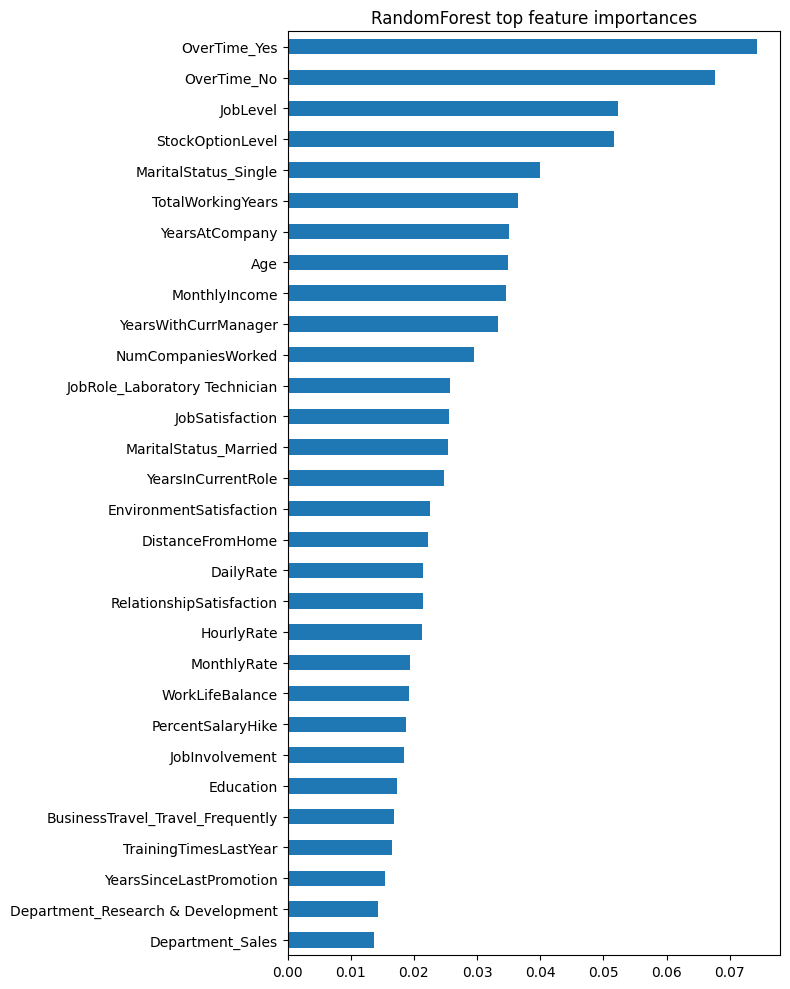

Computing SHAP values (sample)...


In [11]:
# ---------------------
# 8. Feature importance & SHAP
# ---------------------
# Feature importance from RandomForest (if pipeline, extract clf and feature names)
rf_entry = models['RandomForest']
mode_rf, rf_model = rf_entry
if mode_rf == 'pipeline':
    clf_rf = rf_model.named_steps['clf']
    feat_names_num = num_cols
    # get ohe feature names
    ohe = rf_model.named_steps['preproc'].named_transformers_['cat'].named_steps['onehot']
    ohe_cols = ohe.get_feature_names_out(cat_cols).tolist() if cat_cols else []
    feat_names = num_cols + ohe_cols
else:
    # preprocessed model: use preprocessor to get feature names
    feat_names_num = num_cols
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot'] if len(cat_cols)>0 else None
    ohe_cols = ohe.get_feature_names_out(cat_cols).tolist() if (ohe is not None) else []
    feat_names = num_cols + ohe_cols
    clf_rf = rf_model

# compute importances if possible
try:
    importances = clf_rf.feature_importances_
    imp_series = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(30)
    plt.figure(figsize=(8,10))
    imp_series.sort_values().plot(kind='barh')
    plt.title("RandomForest top feature importances")
    plt.tight_layout()
    plt.savefig("figures_attrition/feature_importances_rf.png")
    plt.show()
except Exception as e:
    print("Feature importance not available:", e)

# SHAP explanation (if available)
if SHAP_AVAILABLE:
    print("Computing SHAP values (sample)...")
    # create explainer for tree model
    if mode_rf == 'pipeline':
        X_sample = X_test.sample(min(500, X_test.shape[0]), random_state=42)
        X_sample_pre = rf_model.named_steps['preproc'].transform(X_sample)
        explainer = shap.TreeExplainer(clf_rf)
        shap_values = explainer.shap_values(X_sample_pre)
        # summary plot
        shap.summary_plot(shap_values, features=X_sample_pre, feature_names=feat_names, show=False)
        plt.savefig("figures_attrition/shap_summary_rf.png")
        plt.close()
    else:
        X_sample = X_test.sample(min(500, X_test.shape[0]), random_state=42)
        X_sample_pre = preprocessor.transform(X_sample)
        explainer = shap.TreeExplainer(clf_rf)
        shap_values = explainer.shap_values(X_sample_pre)
        shap.summary_plot(shap_values, features=X_sample_pre, feature_names=feat_names, show=False)
        plt.savefig("figures_attrition/shap_summary_rf.png")
        plt.close()

In [12]:
# ---------------------
# 9. Save best model & preprocessing
# ---------------------
# choose model with best f1 on test (simple selection)
best_name, best_metric = None, -1
for name, entry in models.items():
    mode, mdl = entry
    # get predictions
    if mode == 'pipeline':
        y_pred = mdl.predict(X_test)
    else:
        X_test_pre = preprocessor.transform(X_test)
        y_pred = mdl.predict(X_test_pre)
    f1 = f1_score(y_test, y_pred)
    print(f"{name} test F1: {f1:.4f}")
    if f1 > best_metric:
        best_metric = f1
        best_name = name
        best_model = mdl

print("Best model:", best_name, "with F1:", best_metric)
joblib.dump({
    "model_name": best_name,
    "model": best_model,
    "preprocessor": preprocessor,
    "num_cols": num_cols,
    "cat_cols": cat_cols
}, "employee_attrition_best_model.pkl")
print("Saved model and preprocessor to employee_attrition_best_model.pkl")


LogisticRegression test F1: 0.4390
RandomForest test F1: 0.3429
Best model: LogisticRegression with F1: 0.43902439024390244
Saved model and preprocessor to employee_attrition_best_model.pkl
